### Time Series Forecasting

In [1]:
# Import necessary libs
import pandas as pd
import os
import matplotlib.pyplot as plt

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Load cleaned data
path = ("../data/processed/")

files = sorted([f for f in os.listdir(path) if f.endswith(".parquet")])

dfs = [pd.read_parquet(os.path.join(path, f)) for f in files]

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(3396556, 7)


In [3]:
# Extract Ethiopia Dataset
ethiopia_df = df[
    df["RecipientName"].str.contains("Ethiopia", case=False, na=False)
].copy()

print(ethiopia_df.shape)

(53372, 7)


In [4]:
# Prepare data 
trend = ethiopia_df.groupby("Year")["USD_Commitment"].sum().reset_index()

In [5]:
# ARIMA (core model)

model = ARIMA(trend["USD_Commitment"], order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print(forecast)

10    17949.623831
11    18625.998012
12    18218.154689
13    18464.077997
14    18315.789990
Name: predicted_mean, dtype: float64


#### ARIMA captures trend and temporal dependency in historical climate finance flows, allowing us to generate baseline forcasts.

In [6]:
# We choose Prophet model as it is more 'Policy-Friendly'

df_prophet = trend.reset_index(drop=True)[["Year", "USD_Commitment"]]
df_prophet.columns = ["ds", "y"]

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

print(df_prophet.head())
print(df_prophet.columns)

          ds             y
0 2015-01-01  10462.882644
1 2016-01-01   9109.767152
2 2017-01-01  11597.555898
3 2018-01-01  11432.719352
4 2019-01-01   9801.470944
Index(['ds', 'y'], dtype='object')


13:41:11 - cmdstanpy - INFO - Chain [1] start processing
13:41:11 - cmdstanpy - INFO - Chain [1] done processing


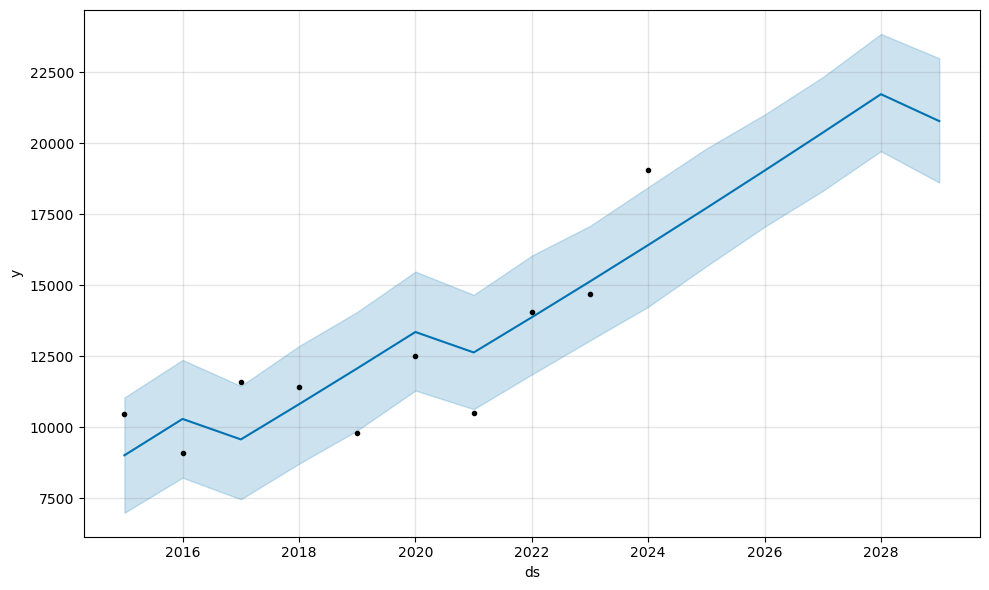

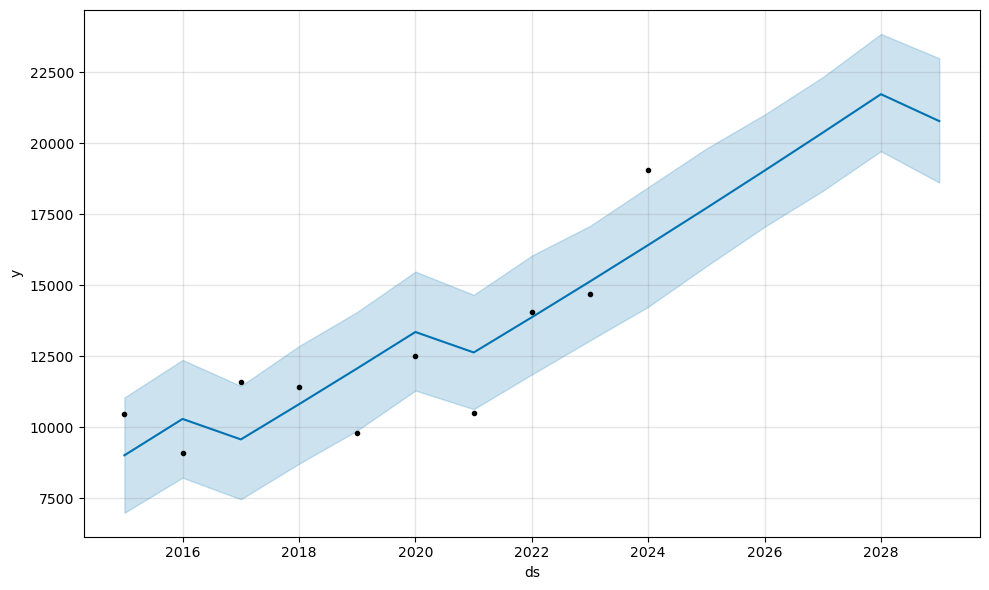

In [7]:
model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=5, freq="Y")
forecast = model.predict(future)

model.plot(forecast)

#### I ensured proper time-series formatting and removed structural inconsistencies in the dataset before applying forecasting models to generate policy-relevant projections.

### Forecast Interpretation

Forecasting results suggest that climate finance to Ethiopia will continue to increase over the medium term; however, the projected growth trajectory remains gradual. This indicates that, without targeted policy interventions, climate finance is unlikely to scale at the pace required to meet long-term resilience and mitigation goals. Additionally, forecast uncertainty highlights dependence on external donor behavior.

#### Compare with scenarios

- Prophet = baseline reality
- Previous Scenarios = Policy choice

The baseline forcast aligns closely with the business-as-usual scenario, reinforcing that current funding patterns are insufficient to significantly improve climate readiness outcomes.

Comparison between statistical forecasting and scenario modeling shows that while current trends indicate steady growth, only policy-driven scenarios—particularly those increasing mitigation investment and climate-targeted finance—lead to meaningful improvements in Ethiopia’s carbon market readiness.

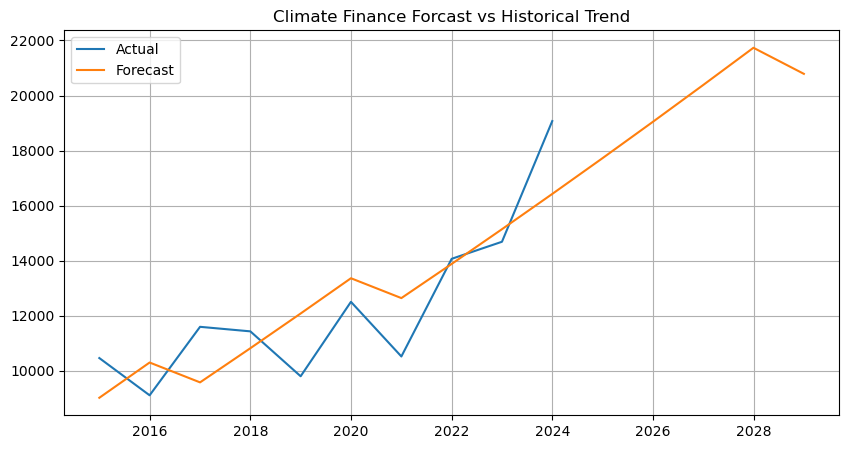

In [9]:
# Add one visual, combining actual data, and Prophet forcast

plt.figure(figsize=(10, 5))

plt.plot(df_prophet["ds"], df_prophet["y"], label="Actual")
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast")

plt.legend()
plt.title("Climate Finance Forcast vs Historical Trend")
plt.grid(True)

plt.savefig("../output/figures/Climate Finance Forcast vs Historical Trend.png", dpi=300, bbox_inches="tight")
plt.show()

Forecasting results indicate that climate finance to Ethiopia is expected to continue increasing over the medium term, following a broadly upward trajectory. However, the forecast assumes relatively stable growth, while historical data reveals periods of volatility driven by large, project-based inflows.

The sharp increase observed in recent years suggests that a portion of climate finance is reactive, likely linked to emergency or crisis-related funding rather than sustained strategic investment. Furthermore, the projected plateau in later years indicates that, without structural improvements—such as diversification of funding sources and increased climate-targeted investment—future growth may slow.

Overall, the forecast reinforces that while Ethiopia is attracting increasing climate finance, current trends alone are insufficient to ensure long-term readiness for carbon markets under Article 6.